# Stage 2 — Mandate Retry Sequencer: Model Training

Trains a model to predict the **probability of success** for a retry across
multiple candidate time windows per failed payment. The agent picks whichever
window the model scores highest for that specific case.

Also runs a naive fixed-schedule baseline on the same batch for an honest
"before vs. after" recovery-rate comparison.

Hard constraints enforced in code (not just described):
- No retry window may fire inside the 24-hour RBI pre-debit notice period
- Max 4 retries within 30 days per payment (checked at simulation level)

Same logic as the original `train_stage2_retry.py` script, split into cells
per the notebook/script split described in `docs/architecture.md` section 7.


In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

np.random.seed(42)

DATA_PATH = "../data/failed_payments.csv"
MODELS_DIR = "../models"
OUTPUTS_DIR = "../outputs"
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# Candidate retry windows, in hours from the original failure.
CANDIDATE_WINDOWS_HOURS = {
    "next_day_morning": 24,
    "next_day_evening": 36,
    "three_days_later": 72,
    "seven_days_later": 168,
}
RBI_MIN_NOTICE_HOURS = 24   # hard constraint — never schedule below this
MAX_RETRIES_PER_30_DAYS = 4  # hard constraint


## 1. Load the combined dataset

In [2]:
df = pd.read_csv(DATA_PATH)
df["is_soft_decline_true"] = df["is_soft_decline_true"].astype(bool)
print(f"Loaded {len(df)} payments")
df.head()


Loaded 1200 payments


,payment_id,customer_name,amount,hour_of_day,day_of_week,retry_count_so_far,past_failure_count,subscription_age_days,decline_reason_true,is_soft_decline_true,is_retriable_true
0,PAY00000,Allison Hill,48.56,16,3,2,1,380,risk_fraud_flag,False,False
1,PAY00001,Noah Rhodes,21.48,9,1,1,1,17,insufficient_funds_or_technical,True,True
2,PAY00002,Angie Henderson,16.82,10,5,0,1,119,insufficient_funds_or_technical,True,True
3,PAY00003,Daniel Wagner,56.86,15,1,0,1,556,card_expired,False,False
4,PAY00004,Cristian Santos,10.76,20,5,1,1,214,insufficient_funds_or_technical,True,True


## 2. Simulate retry outcomes per candidate window

Ground-truth simulation grounded in the research: soft declines are
recoverable, waiting longer (closer to a plausible payday cycle) improves
odds up to a point, and customers with more past failures are harder to
recover.

In [3]:
def simulate_retry_success(reason_soft: bool, window_hours: int, past_failures: int) -> int:
    base = 0.55 if reason_soft else 0.05
    if window_hours in (72, 168):
        base += 0.15
    elif window_hours == 24:
        base += 0.02
    base -= 0.05 * min(past_failures, 3)
    base = np.clip(base + np.random.normal(0, 0.08), 0, 1)
    return int(np.random.rand() < base)


def build_candidate_rows(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, r in df.iterrows():
        for window_name, hours in CANDIDATE_WINDOWS_HOURS.items():
            if hours < RBI_MIN_NOTICE_HOURS:
                continue  # hard constraint enforced here, not just documented
            success = simulate_retry_success(
                r["is_soft_decline_true"], hours, r["past_failure_count"]
            )
            rows.append({
                "payment_id": r["payment_id"],
                "amount": r["amount"],
                "hour_of_day": r["hour_of_day"],
                "day_of_week": r["day_of_week"],
                "past_failure_count": r["past_failure_count"],
                "is_soft_decline_true": int(r["is_soft_decline_true"]),
                "window_hours": hours,
                "window_name": window_name,
                "retry_success": success,
            })
    return pd.DataFrame(rows)

candidates = build_candidate_rows(df)
print(f"Built {len(candidates)} candidate-window rows from {len(df)} payments")
candidates.head()


Built 4800 candidate-window rows from 1200 payments


,payment_id,amount,hour_of_day,day_of_week,past_failure_count,is_soft_decline_true,window_hours,window_name,retry_success
0,PAY00000,48.56,16,3,1,0,24,next_day_morning,0
1,PAY00000,48.56,16,3,1,0,36,next_day_evening,0
2,PAY00000,48.56,16,3,1,0,72,three_days_later,1
3,PAY00000,48.56,16,3,1,0,168,seven_days_later,0
4,PAY00001,21.48,9,1,1,1,24,next_day_morning,1


## 3. Train/test split + train the model

In [4]:
feature_cols = ["amount", "hour_of_day", "day_of_week",
                 "past_failure_count", "is_soft_decline_true", "window_hours"]
X = candidates[feature_cols]
y = candidates["retry_success"]

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, candidates.index, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)
model.fit(X_train, y_train)

test_probs = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, test_probs)
print(f"Held-out test ROC-AUC: {auc:.3f}")


Held-out test ROC-AUC: 0.812


## 4. Naive vs. smart comparison

Evaluated on a fresh held-out set of **payments** (not just rows) for a fair,
payment-level comparison.

In [5]:
test_payment_ids = df.sample(frac=0.3, random_state=7)["payment_id"].tolist()
eval_candidates = candidates[candidates["payment_id"].isin(test_payment_ids)].copy()
eval_candidates["predicted_prob"] = model.predict_proba(eval_candidates[feature_cols])[:, 1]

# SMART strategy: pick the window with the highest predicted success probability per payment
smart_choice = eval_candidates.loc[
    eval_candidates.groupby("payment_id")["predicted_prob"].idxmax()
]
smart_recovery_rate = smart_choice["retry_success"].mean()

# NAIVE baseline: always retry at the first compliant window (24h)
naive_choice = eval_candidates[eval_candidates["window_name"] == "next_day_morning"]
naive_recovery_rate = naive_choice["retry_success"].mean()

lift = (smart_recovery_rate - naive_recovery_rate) / naive_recovery_rate * 100

print(f"Naive fixed-schedule recovery rate:  {naive_recovery_rate:.1%}")
print(f"Smart model-picked recovery rate:    {smart_recovery_rate:.1%}")
print(f"Relative lift from smart retries:    {lift:+.1f}%")


Naive fixed-schedule recovery rate:  29.4%
Smart model-picked recovery rate:    51.1%
Relative lift from smart retries:    +73.6%


## 5. Stopping-rule sanity check

In [6]:
retries_per_payment = eval_candidates.groupby("payment_id").size()
violations = int((retries_per_payment > MAX_RETRIES_PER_30_DAYS).sum())
print(f"Payments exceeding the {MAX_RETRIES_PER_30_DAYS}-retry/30-day cap: {violations}")


Payments exceeding the 4-retry/30-day cap: 0


## 6. Comparison chart

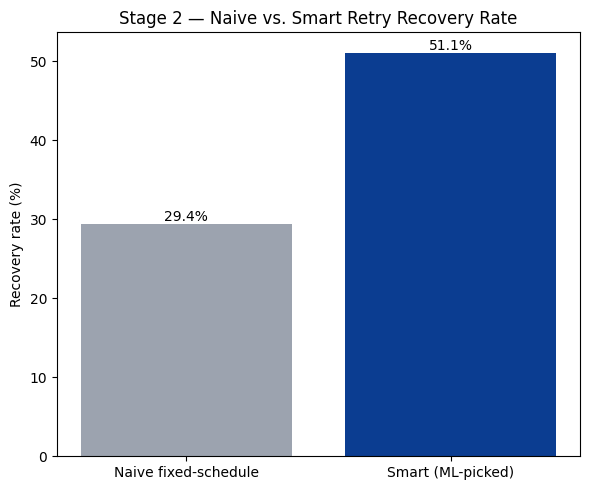

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(
    ["Naive fixed-schedule", "Smart (ML-picked)"],
    [naive_recovery_rate * 100, smart_recovery_rate * 100],
    color=["#9ca3af", "#0b3d91"]
)
ax.set_ylabel("Recovery rate (%)")
ax.set_title("Stage 2 — Naive vs. Smart Retry Recovery Rate")
for b in bars:
    h = b.get_height()
    ax.annotate(f"{h:.1f}%", (b.get_x() + b.get_width() / 2, h), ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/stage2_comparison.png", dpi=150)
plt.show()


## 7. Save the trained model

This is the file the FastAPI backend loads at `backend/app/stage2_retry/sequencer.py`
— it applies this model's predictions plus the RBI/stopping-rule constraints live.

In [8]:
model_bundle = {
    "model": model,
    "feature_cols": feature_cols,
    "candidate_windows_hours": CANDIDATE_WINDOWS_HOURS,
    "rbi_min_notice_hours": RBI_MIN_NOTICE_HOURS,
    "max_retries_per_30_days": MAX_RETRIES_PER_30_DAYS,
}
joblib.dump(model_bundle, f"{MODELS_DIR}/stage2_retry_model.pkl")
print(f"Saved: {MODELS_DIR}/stage2_retry_model.pkl")


Saved: ../models/stage2_retry_model.pkl
